In [293]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

Aqui eu defini a palheta de cores para deixar parecida com a cor da amazon 

In [294]:
amazon_palette = sns.light_palette("#FF9900", n_colors=6)

In [295]:
sns.color_palette('Oranges', 8)

[(0.996555171088043, 0.9091118800461361, 0.8216685890042291),
 (0.9931103421760862, 0.8366628219915417, 0.6772472126105344),
 (0.9921568627450981, 0.726797385620915, 0.49150326797385624),
 (0.9921568627450981, 0.6118108419838524, 0.3191387927720108),
 (0.9707497116493656, 0.488719723183391, 0.1621530180699731),
 (0.9137254901960784, 0.3686274509803921, 0.050980392156862744),
 (0.8023529411764706, 0.2651903114186851, 0.005828527489427143),
 (0.6323875432525952, 0.20461361014994234, 0.01224144559784698)]

In [296]:
df_amazon = pd.read_csv('../data/raw/amazon_delivery.csv')

In [297]:
df_amazon.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


In [298]:
df_amazon.describe()

,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Delivery_Time
count,43739.000000,43685.000000,43739.000000,43739.000000,43739.000000,43739.000000,43739.000000
mean,29.567137,4.633780,17.210960,70.661177,17.459031,70.821842,124.905645
std,5.815155,0.334716,7.764225,21.475005,7.342950,21.153148,51.915451
min,15.000000,1.000000,-30.902872,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.500000,12.933298,73.170283,12.985996,73.280000,90.000000
50%,30.000000,4.700000,18.551440,75.898497,18.633626,76.002574,125.000000
75%,35.000000,4.900000,22.732225,78.045359,22.785049,78.104095,160.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,270.000000


In [299]:
df_amazon.info()

<class 'pandas.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  str    
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  str    
 8   Order_Time       43739 non-null  str    
 9   Pickup_Time      43739 non-null  str    
 10  Weather          43648 non-null  str    
 11  Traffic          43739 non-null  str    
 12  Vehicle          43739 non-null  str    
 13  Area             43739 non-null  str    
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  str    
dtypes: float64(5), int64(2), str(9)
memory usage: 8.6 MB


In [300]:
df_amazon.nunique()

Order_ID           43739
Agent_Age             22
Agent_Rating          28
Store_Latitude       521
Store_Longitude      415
Drop_Latitude       4367
Drop_Longitude      4367
Order_Date            44
Order_Time           177
Pickup_Time          193
Weather                6
Traffic                5
Vehicle                4
Area                   4
Delivery_Time         89
Category              16
dtype: int64

Aqui eu fui ver os valores que aparecem quando a categoria contem < 10 elementos distintos

In [301]:
df_amazon['Weather'].unique()

<ArrowStringArray>
['Sunny', 'Stormy', 'Sandstorms', 'Cloudy', 'Fog', 'Windy', nan]
Length: 7, dtype: str

In [302]:
df_amazon['Traffic'].unique()

<ArrowStringArray>
['High ', 'Jam ', 'Low ', 'Medium ', 'NaN ']
Length: 5, dtype: str

In [303]:
df_amazon['Vehicle'].unique()

<ArrowStringArray>
['motorcycle ', 'scooter ', 'van', 'bicycle ']
Length: 4, dtype: str

In [304]:
df_amazon['Area'].unique()

<ArrowStringArray>
['Urban ', 'Metropolitian ', 'Semi-Urban ', 'Other']
Length: 4, dtype: str

- Here it was discovered that there were other variables with NaN values, but they were in string format.
- And have variables whith incorrect spaces.

# Remover espaços em branco

In [305]:
coluna_str = df_amazon.select_dtypes(include = ['object']).columns
print(coluna_str)

Index(['Order_ID', 'Order_Date', 'Order_Time', 'Pickup_Time', 'Weather',
       'Traffic', 'Vehicle', 'Area', 'Category'],
      dtype='str')


/tmp/ipykernel_6695/2299788345.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  coluna_str = df_amazon.select_dtypes(include = ['object']).columns


In [306]:
coluna = list(df_amazon.columns)

In [307]:
df_amazon2 = df_amazon

In [308]:
for coluna in coluna_str:
    df_amazon2[coluna] = df_amazon[coluna].str.strip()

In [309]:
teste = df_amazon2[df_amazon2['Order_Time']=='NaN']
teste['Order_Time'].value_counts().sum()

np.int64(91)

In [310]:
df_amazon2['Order_Time'].unique()

<ArrowStringArray>
['11:30:00', '19:45:00', '08:30:00', '18:00:00', '13:30:00', '21:20:00',
 '19:15:00', '17:25:00', '20:55:00', '21:55:00',
 ...
 '14:00:00', '15:40:00', '16:25:00', '14:10:00', '13:45:00', '13:55:00',
 '14:35:00',      'NaN', '16:30:00', '14:45:00']
Length: 177, dtype: str

Depois disso decidi trocar todos as string 'NaN' por valores nan reais

In [311]:
for coluna in coluna_str:
    df_amazon2[coluna] = df_amazon2[coluna].replace('NaN', np.nan)

In [312]:
df_amazon = df_amazon2

How much data is missing from the dataset ?

In [313]:
df_amazon.isna().sum()

Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time         91
Pickup_Time         0
Weather            91
Traffic            91
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

In [314]:
df_amazon[df_amazon['Agent_Rating'].isna()].head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
124,uurs547552548,23,NaN,22.569358,88.433452,22.599358,88.463452,2022-02-17,23:25:00,23:35:00,Sunny,Low,motorcycle,Metropolitian,75,Snacks
1996,xoaj834389107,32,NaN,0.000000,0.000000,0.050000,0.050000,2022-02-11,20:50:00,21:00:00,Sandstorms,Jam,motorcycle,Urban,185,Snacks
2002,lasr795083832,23,NaN,25.454648,81.834502,25.584648,81.964502,2022-02-18,19:50:00,19:55:00,Windy,Jam,motorcycle,Metropolitian,150,Outdoors
2018,gjcr517387117,26,NaN,0.000000,0.000000,0.080000,0.080000,2022-02-16,23:50:00,23:55:00,Cloudy,Low,scooter,Metropolitian,140,Clothing
3253,ohgx024912559,32,NaN,19.874733,75.353942,19.984733,75.463942,2022-02-16,18:35:00,18:50:00,Sandstorms,Medium,motorcycle,Metropolitian,170,Kitchen


In [315]:
df_amazon[df_amazon['Weather'].isna()].head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
2286,xige084493792,15,1.0,-26.891191,75.802083,26.981191,75.892083,2022-03-12,NaN,17:20:00,NaN,NaN,motorcycle,Urban,75,Home
2779,oilg311747812,15,1.0,22.750040,75.902847,22.810040,75.962847,2022-04-03,NaN,20:30:00,NaN,NaN,scooter,Metropolitian,145,Kitchen
2825,pbox816153129,15,1.0,21.149569,72.772697,21.209569,72.832697,2022-03-21,NaN,22:10:00,NaN,NaN,bicycle,Metropolitian,100,Clothing
3438,nzsa056960624,50,6.0,-12.970324,-77.645748,13.010324,77.685748,2022-03-13,NaN,12:30:00,NaN,NaN,van,Urban,125,Cosmetics
4514,eids248121351,50,6.0,-17.451976,-78.385883,17.561976,78.495883,2022-04-04,NaN,23:20:00,NaN,NaN,bicycle,Metropolitian,135,Jewelry


- Também descobri que tem algumas colunas onde a localização da loja e do ponto de entrega estão errados.
- Decidi ver quantos % do dataset é igual a 0

# Comecei a ver sobre a localização invalida 

In [316]:
len(df_amazon)

43739

In [317]:
NaN_store_latitude = (df_amazon["Store_Latitude"] == 0).sum() / len(df_amazon)
print(f'The % of NaN Latitude value is: {NaN_store_latitude*100:.2f}%')

The % of NaN Latitude value is: 8.01%


In [318]:
(df_amazon["Store_Latitude"] == 0).sum()

np.int64(3505)

In [319]:
NaN_store_longitude = (df_amazon["Store_Longitude"] == 0).sum() / len(df_amazon)
print(f'The % of NaN Latitude value is: {NaN_store_longitude*100:.2f}%')

The % of NaN Latitude value is: 8.01%


In [320]:
(df_amazon["Store_Longitude"] == 0).sum()

np.int64(3505)

In [321]:
NaN_drop_latitude = (df_amazon['Drop_Latitude'] == 0).sum() / len(df_amazon)
print(f'The % of NaN Latitude value is: {NaN_drop_latitude*100:.2f}%')

The % of NaN Latitude value is: 0.00%


In [322]:
NaN_drop_longitude = df_amazon.query('Drop_Longitude == 0').value_counts().sum() / len(df_amazon)
print(f'The % of NaN Latitude value is: {NaN_drop_longitude*100:.2f}%')

The % of NaN Latitude value is: 0.00%


In [323]:
pd.crosstab(
    df_amazon["Store_Latitude"] == 0,
    df_amazon["Store_Longitude"] == 0
)

Store_Longitude,False,True
Store_Latitude,,
False,40234,0
True,0,3505


- Aqui descobri que os valores nulos ocorrem apenas nas mesmas linhas, provavelmente por ter apresentado alguma inconsistencia na coleta desses dados.
- Decidi remover esses registros, pois a imputação da mediana para latitude e longitude criaria localizações artificiais. Como essas coordenadas serão utilizadas para calcular a distância entre a loja e o destino, isso produziria valores inconsistentes em relação ao tempo de entrega (target), podendo prejudicar o treinamento do modelo.
- Aqui decidi averiguar melhor os dados do Drop

In [324]:
df_amazon['Drop_Latitude'].sort_values(ascending=True).head()

450      0.01
37393    0.01
37389    0.01
17163    0.01
10637    0.01
Name: Drop_Latitude, dtype: float64

In [325]:
(df_amazon['Drop_Latitude'] <= 1).sort_values(ascending=True).value_counts()

Drop_Latitude
False    40234
True      3505
Name: count, dtype: int64

In [326]:
Incorrect_drop_longitude = (df_amazon['Drop_Latitude'] <= 1).sum() / len(df_amazon['Drop_Latitude'])
print(f'The % of NaN Latitude value is: {Incorrect_drop_longitude*100:.2f}%')

The % of NaN Latitude value is: 8.01%


In [327]:
pd.crosstab(
    df_amazon['Store_Latitude'] == 0, 
    df_amazon['Drop_Latitude'] >= 1
)

Drop_Latitude,False,True
Store_Latitude,,
False,0,40234
True,3505,0


- Depois de ver esses dados, segui por ver entre quais coordenadas fariam sentido realmente existir os dados, depois de pesquisar, cheguei que a Índia estende-se por uma ampla variação de coordenadas geográficas. Em latitude, varia de 8°4'N (sul do continente) a 37°6'N (norte). Em longitude, varia de 68°7'L (oeste) a 97°25'L (leste). 

How to Convert Degrees Minutes Seconds to Decimal Degrees: 

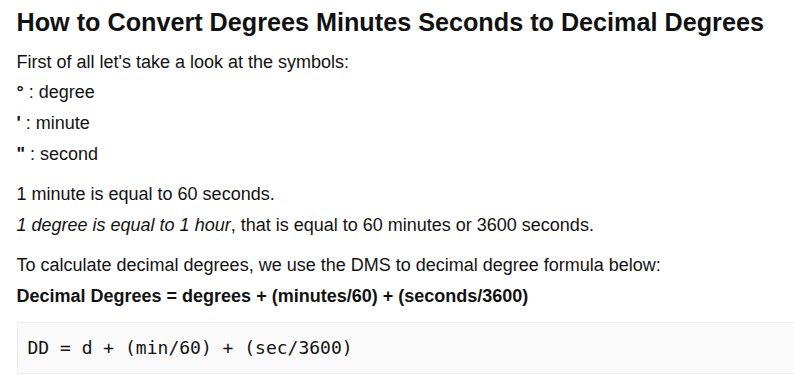

In [335]:
#Latitude Sul da Índia
Min_Latitude = 8+4/60
print(f'The min possible Latitude is: {Min_Latitude:.3f}')

Max_Latitude = 37+6/60
print(f'The max possible Latitude is: {Max_Latitude:.3f}')

Min_Longitude = 68+7/60
print(f'The min possible Longitude is: {Min_Longitude:.3f}')

Max_Longitude = 97+25/60
print(f'The max possible Longitude is: {Max_Longitude:.3f}')

The min possible Latitude is: 8.067
The max possible Latitude is: 37.100
The min possible Longitude is: 68.117
The max possible Longitude is: 97.417


In [353]:
invalid_store_values = (
    ((df_amazon['Store_Latitude']) < Min_Latitude) | ((df_amazon['Store_Latitude']) > Max_Latitude) |
    ((df_amazon['Store_Longitude']) < Min_Longitude) | ((df_amazon['Store_Longitude']) > Max_Longitude)
)

invalid_drop_values = (
    ((df_amazon['Drop_Latitude']) < Min_Latitude) | ((df_amazon['Drop_Latitude']) > Max_Latitude) |
    ((df_amazon['Drop_Longitude']) < Min_Longitude) | ((df_amazon['Drop_Longitude']) > Max_Longitude)
)

print(f'A quantidade de dados da Store invalidos são: {invalid_store_values.sum()}')
print(f'A quantidade de dados do Drop invalidos são: {invalid_drop_values.sum()}')


A quantidade de dados da Store invalidos são: 3693
A quantidade de dados do Drop invalidos são: 3505


In [354]:
df_amazon[invalid_drop_values]['Area'].value_counts(normalize=True)

Area
Metropolitian    0.735806
Urban            0.235949
Other            0.024251
Semi-Urban       0.003994
Name: proportion, dtype: float64

In [331]:
df_amazon[mask_invalid]["Weather"].value_counts(normalize=True)

Weather
Fog           0.180544
Stormy        0.170243
Cloudy        0.168240
Windy         0.164235
Sandstorms    0.161087
Sunny         0.155651
Name: proportion, dtype: float64

In [332]:
df_amazon[mask_invalid]["Traffic"].value_counts(normalize=True)

Traffic
Low       0.355079
Jam       0.305579
Medium    0.240343
High      0.098999
Name: proportion, dtype: float64

In [333]:
df_amazon.groupby(mask_invalid)["Delivery_Time"].describe()

,count,mean,std,min,25%,50%,75%,max
False,40234.0,125.063628,51.902666,10.0,90.0,125.0,160.0,270.0
True,3505.0,123.092154,52.035056,10.0,85.0,120.0,155.0,270.0


In [334]:
df_amazon[df_amazon["Store_Latitude"] == 0]["Area"].value_counts(normalize=True)

Area
Metropolitian    0.735806
Urban            0.235949
Other            0.024251
Semi-Urban       0.003994
Name: proportion, dtype: float64

# Resolver a questão da localização (Se for necessario, dropar as colunas aqui)

# Separar o conjunto em X e y

# EDA (como quantos % cada localização tem na área)

# Limpeza dos dados

# Calculo da localização e criação da feature distância